# Taller 1 Ecuacciones Diferenciales Ordinarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Primer Orden

In [2]:
def Euler(f, x0, y0, h, x_end):
    """
    Implementa el método de Euler para resolver una Ecuación Diferencial Ordinaria (EDO) de primer orden.
    y(xn + 1) = y(xn) + h * f(xn, yn)

    Args:
        f: La función que define la EDO, dy/dx = f(x, y). Debe aceptar dos argumentos: x e y. -> Callable
        x0: La condición inicial para la variable independiente (x). -> float
        y0: La condición inicial para la variable dependiente (y) en x0. -> float
        h: El tamaño del paso (incremento en x) para la iteración. -> float
        x_end: El valor final de x hasta donde se desea aproximar la solución. -> float

    Returns:
        Una tupla (x, y) donde:
        x: Un arreglo numpy con los valores de x en cada paso. -> Array
        y: Un arreglo numpy con las aproximaciones de y correspondientes a cada valor de x. -> Array
    """
    # Calcular el número de pasos necesarios para ir de x0 a x_end con un tamaño de paso h.
    n_steps = int((x_end - x0) / h)

    # Inicializar arreglos numpy para almacenar los valores de x e y en cada paso.
    # Se crea un espacio para n_steps + 1 puntos, incluyendo el punto inicial.
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)

    # Establecer la condición inicial en el primer elemento de los arreglos.
    x[0] = x0
    y[0] = y0

    # Iterar sobre el número de pasos para aplicar la fórmula del método de Euler.
    for i in range(n_steps):
        # Calcular el siguiente valor de x sumando el tamaño del paso h al valor actual de x.
        x[i+1] = x[i] + h
        # Aplicar la fórmula del método de Euler para calcular la aproximación del siguiente valor de y:
        # y[i+1] = y[i] + h * f(x[i], y[i])
        # donde f(x[i], y[i]) es la pendiente en el punto actual (x[i], y[i]) según la EDO.
        y[i+1] = y[i] + h * f(x[i], y[i])

    # Devolver los arreglos de valores de x e y calculados.
    return x, y
     

# 1 
El número de átomos radiactivos que decaen en un período de tiempo dado es proporcional al número de átomos en la muestra:

$$
\frac{dN}{dt} = -\lambda N
$$

con $\lambda=\frac{\ln{2}}{t_{1/2}}$ siendo $t_{1/2}$ el tiempo de vida media.

Escriba un programa que utilice el método de Euler para graficar $N(t)$. Compare con la solución exacta, $N(t) = N_0 e^{-\lambda t}$, para comparación. Tome $N_0=1000$ y $t_{1/2}=15$ horas, lo cual es el valor para el $^{24}Na$.

In [3]:
# Parameters
N0 = 1000  # Initial number of atoms
t1_2=15 #En horas para el plutonio
lambda_ = np.log(2)/t1_2  # Decay constant
t_max = 70  # Maximum time
dt = 0.1  # Time step
f=lambda t,N: -lambda_*N  #f(t,N)

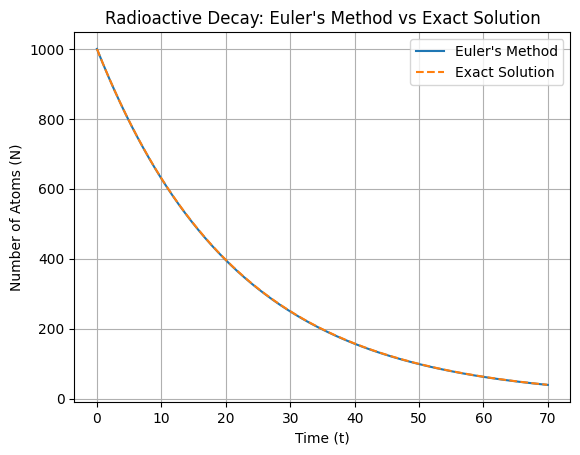

In [4]:
# Euler's method
t_euler=Euler(f,0,N0,dt,t_max)[0]
N_euler = Euler(f,0,N0,dt,t_max)[1]
# Exact solution
t = np.arange(0, t_max, dt)
N_exact = N0 * np.exp(-lambda_ * t)

# Plotting
plt.plot(t_euler, N_euler, label="Euler's Method")
plt.plot(t, N_exact, label="Exact Solution", linestyle='--')
plt.xlabel('Time (t)')
plt.ylabel('Number of Atoms (N)')
plt.title('Radioactive Decay: Euler\'s Method vs Exact Solution')
plt.legend()
plt.grid()
plt.show()

Otra alternativa sin utilizar la función previa

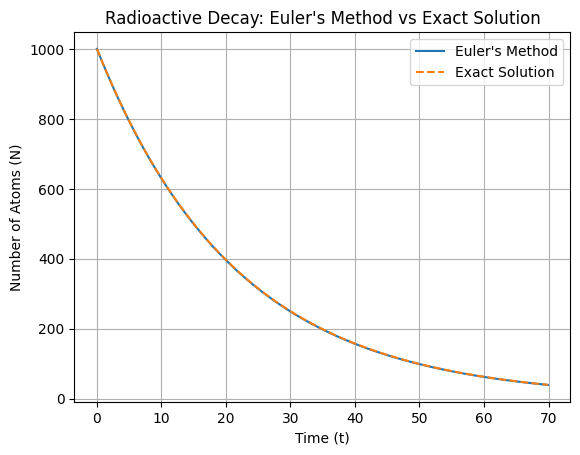

In [5]:
# Time array
t = np.arange(0, t_max, dt)

# Euler's method
N_euler = np.zeros(len(t))
N_euler[0] = N0

for i in range(1, len(t)):
    N_euler[i] = N_euler[i-1] -lambda_ * N_euler[i-1] * dt

# Exact solution
N_exact = N0 * np.exp(-lambda_ * t)

# Plotting
plt.plot(t, N_euler, label="Euler's Method")
plt.plot(t, N_exact, label="Exact Solution", linestyle='--')
plt.xlabel('Time (t)')
plt.ylabel('Number of Atoms (N)')
plt.title('Radioactive Decay: Euler\'s Method vs Exact Solution')
plt.legend()
plt.grid()
plt.show()

### Segundo orden

In [6]:
def Euler_orden2(f, t0, y0, yp0, h, t_end):
    """
    Implementa el método de Euler para resolver una Ecuación Diferencial Ordinaria (EDO) de segundo orden.

    Se considera una EDO de la forma:
        d²y/dt² = f(t, y, dy/dt)
    que se transforma en un sistema de primer orden:
        dy/dt = v
        dv/dt = f(t, y, v)

    Args:
        f: La función que define la segunda derivada, d²y/dt² = f(t, y, dy/dt). Debe aceptar tres argumentos: t, y, dy/dt. -> Callable
        t0: La condición inicial para la variable independiente (t). -> float
        y0: La condición inicial para la variable dependiente (y) en t0. -> float
        yp0: La condición inicial para la derivada de y (dy/dt) en t0. -> float
        h: El tamaño del paso (incremento en t) para la iteración. -> float
        t_end: El valor final de t hasta donde se desea aproximar la solución. -> float

    Returns:
        Una tupla (t, y, yp) donde:
        t: Un arreglo numpy con los valores de t en cada paso. -> ndarray
        y: Un arreglo numpy con las aproximaciones de y correspondientes a cada valor de t. -> ndarray
        yp: Un arreglo numpy con las aproximaciones de dy/dt correspondientes a cada valor de t. -> ndarray
    """
    # Calcular el número total de pasos requeridos
    n_steps = int((t_end - t0) / h)

    # Inicializar arreglos para el tiempo, la función y su derivada
    t = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)
    yp = np.zeros(n_steps + 1)

    # Establecer las condiciones iniciales
    t[0] = t0
    y[0] = y0
    yp[0] = yp0

    # Aplicar el método de Euler paso a paso
    for i in range(n_steps):
        t[i+1] = t[i] + h                      # Avanza el tiempo
        y[i+1] = y[i] + h * yp[i]              # Calcula y con dy/dt = yp
        yp[i+1] = yp[i] + h * f(t[i], y[i], yp[i])  # Calcula dy/dt con d²y/dt² = f

    return t, y, yp

# 2
El péndulo de la figura está suspendido de un collar deslizante. El sistema está en reposo cuando se le impone un movimiento oscilante $y(t)=Y \sin{\omega t}$ sobre la cuenta, comenzando en $t=0$. La ecuación diferencial que describe el movimiento del péndulo es

$$\ddot{\theta}=-\frac{g}{L} \sin{\theta} + \frac{\omega^2}{L}Y \cos{\theta}\sin{\omega t} $$

Grafique $\theta$ vs $t$ con $0\leq t \leq 10s$ y determine el $\theta$ mayor en este intervalo. Use $g=9.8 \ m/s^2$, $L=1.0 \ m$, $Y=0.25 \ m$ y $\omega=2.5 \ rad/s$. Con $\theta(0)=0$ y $\dot{\theta}(0)=0.1$.

<center>

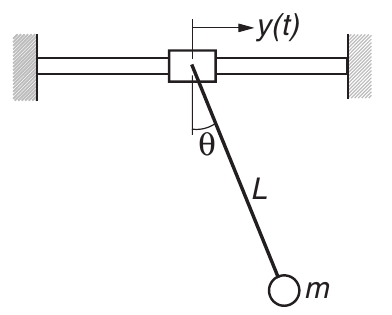

</center>

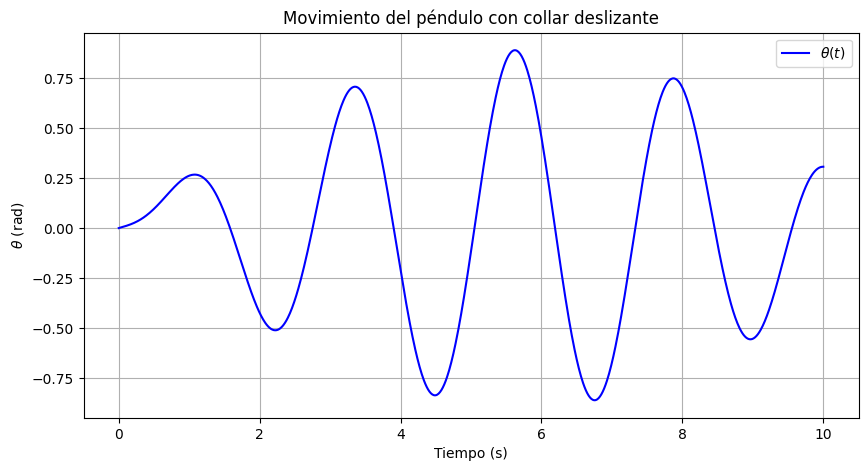

In [7]:
# Parámetros del problema
g = 9.8
L = 1.0
Y = 0.25
omega = 2.5

# Definir la función f(t, theta, theta_p) = theta_pp
def f(t, theta, theta_p):
    return - (g / L) * np.sin(theta) + (omega**2 / L) * Y * np.cos(theta) * np.sin(omega * t)

# Condiciones iniciales
theta0 = 0.0       # theta(0) = 0
theta_p0 = 0.1      # theta'(0) = 0.1

# Configuración de la integración
t0 = 0.0
t_end = 10.0
h = 0.01  # Paso de tiempo

# Resolver la EDO
t, theta, theta_p = Euler_orden2(f, t0, theta0, theta_p0, h, t_end)

# Graficar theta(t)
plt.figure(figsize=(10, 5))
plt.plot(t, theta, label=r'$\theta(t)$', color='blue')
plt.xlabel('Tiempo (s)')
plt.ylabel(r'$\theta$ (rad)')
plt.title('Movimiento del péndulo con collar deslizante')
plt.grid()
plt.legend()
plt.show()

In [8]:
# Encontrar el valor máximo de theta en el intervalo
theta_max = np.max(np.abs(theta))  # Valor máximo en magnitud
theta_max_rad = theta_max
theta_max_deg = np.degrees(theta_max_rad)  # Convertir a grados para referencia

print(f"El valor máximo de theta en el intervalo es: {theta_max_rad:.4f} rad ({theta_max_deg:.2f}°)")

El valor máximo de theta en el intervalo es: 0.8901 rad (51.00°)


### Matricial

In [9]:
def euler_matrix_method(A, b, y0, h, x0, x_end):
    """
    Método de Euler matricial para resolver dY/dx = A*Y + b

    Parámetros:
    A: Matriz del sistema (numpy array de tamaño n x n)
    b: Vector  (numpy array de tamaño n)
    y0: Vector de condiciones iniciales (numpy array de tamaño n)
    h: Tamaño del paso
    x0: Valor inicial de x
    x_end: Valor final de x

    Retorna:
    x: Vector de valores de x
    Y: Matriz donde cada fila representa el vector Y en cada paso
    """
    # Calcular el número de pasos
    n_steps = int((x_end - x0) / h)

    # Dimensión del sistema
    n = len(y0)

    # Inicializar arreglos
    x = np.zeros(n_steps + 1)
    Y = np.zeros((n_steps + 1, n))

    # Establecer condiciones iniciales
    x[0] = x0
    Y[0] = y0

    # Matriz de evolución
    evolution_matrix = np.eye(n) + h * A

    # Iterar aplicando el método de Euler
    for i in range(n_steps):
        x[i+1] = x[i] + h
        Y[i+1] = evolution_matrix @ Y[i] + h * b(x[i])  

    return x, Y

# 3.

<center>

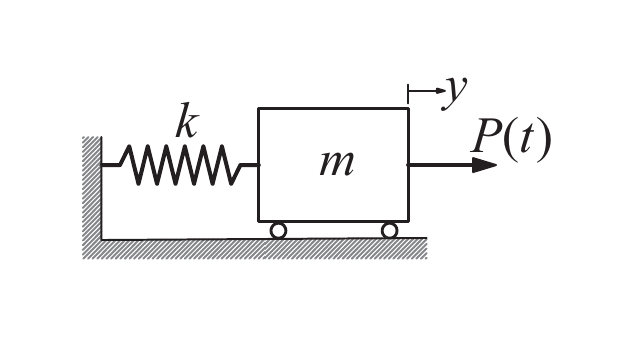

</center>

El sistema masa-resorte está en reposo cuando se aplica la fuerza \( P(t) \), donde

$$
P(t) = 
\begin{cases} 
10t \, \text{N} & \text{cuando } t < 2 \, \text{s} \\
20 \, \text{N} & \text{cuando } t \geq 2 \, \text{s}
\end{cases}
$$

La ecuación diferencial del movimiento resultante es

$$
\ddot{y} = \frac{P(t)}{m} - \frac{k}{m} y
$$

Determine el desplazamiento máximo de la masa. Usa $m = 2.5 \, \text{kg}$ y $k = 75 \, \text{N/m}$.


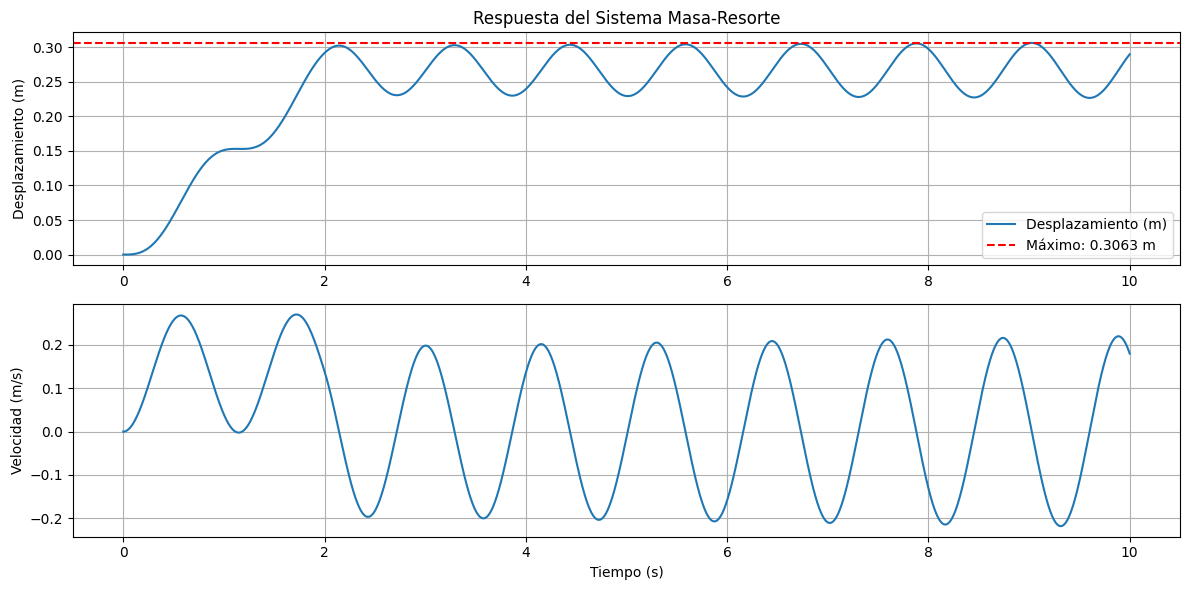

El máximo desplazamiento es: 0.3063 m ocurre en t = 9.03 s


In [10]:
# Parámetros del sistema
m = 2.5  # kg
k = 75   # N/m

# Definir la fuerza P(t)
def P(t):
    if t < 2:
        return 10 * t
    else:
        return 20

# Definir la matriz A y la función b(t)
A=np.array([[0, 1], [-k/m, 0]])


def b_vector(t):
    return np.array([0, P(t)/m])

# Condiciones iniciales (sistema en reposo)
y0 = np.array([0.0, 0.0])

# Parámetros de la simulación
t0 = 0.0
t_end = 10.0
h = 0.001

# Resolver el sistema
t, Y = euler_matrix_method(A, b_vector, y0, h, t0, t_end)

# Extraer el desplazamiento (y1) y la velocidad (y2)
y1 = Y[:, 0]
y2 = Y[:, 1]

# Encontrar el máximo desplazamiento
max_disp = np.max(np.abs(y1))
max_disp_time = t[np.argmax(np.abs(y1))]

# Graficar los resultados
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, y1, label='Desplazamiento (m)')
plt.axhline(y=max_disp, color='r', linestyle='--', label=f'Máximo: {max_disp:.4f} m')
plt.legend()
plt.grid()
plt.ylabel('Desplazamiento (m)')
plt.title('Respuesta del Sistema Masa-Resorte')

plt.subplot(2, 1, 2)
plt.plot(t, y2, label='Velocidad (m/s)')
plt.grid()
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')

plt.tight_layout()
plt.show()

print(f"El máximo desplazamiento es: {max_disp:.4f} m ocurre en t = {max_disp_time:.2f} s")

# 4.
$$
\frac{dy_1}{dx} = -2y_1 + 2y_2 + 1 
$$
$$
\frac{dy_2}{dx} = y_1 - 3y_2 + 2x
$$

Con $y_1(0)=1$ y $y_2(0)=0$.

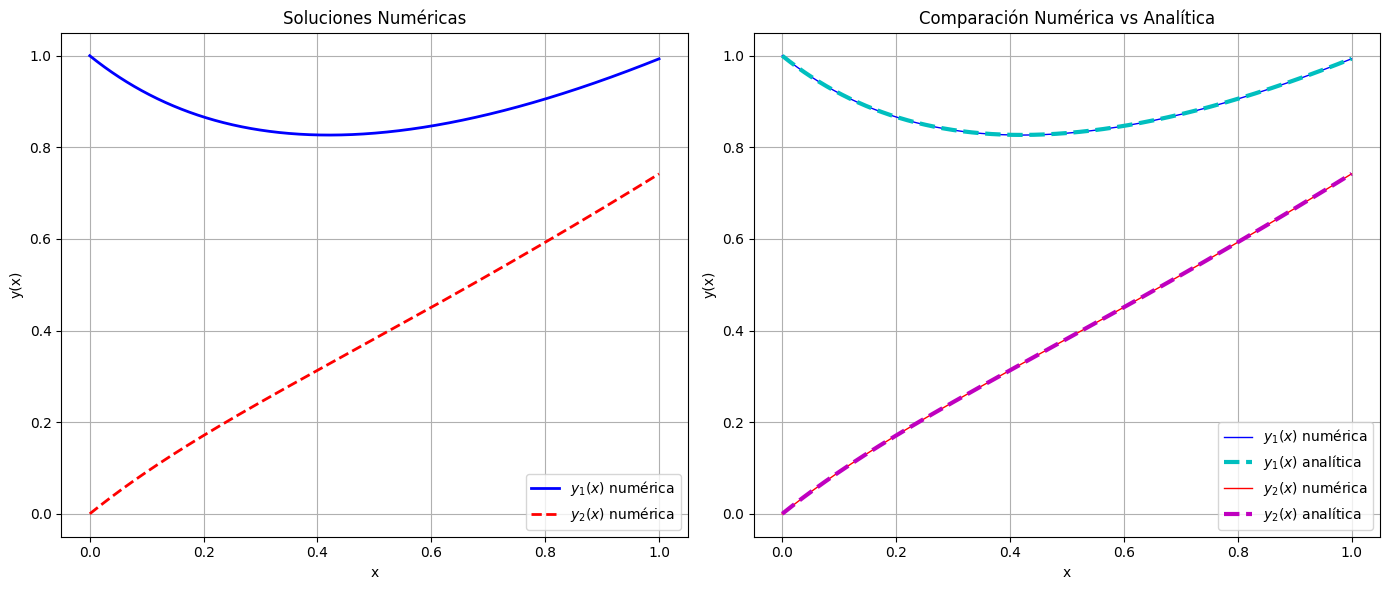

In [11]:
# Definimos el sistema
A = np.array([[-2, 2], 
              [1, -3]])

def b(x):
    return np.array([1,2*x])

# Condiciones iniciales
y0 = np.array([1, 0])

# Parámetros de la solución
x0 = 0
x_end = 1
h = 0.001

# Resolver el sistema
x_num, Y_num = euler_matrix_method(A, b, y0, h, x0, x_end)

# Soluciones analíticas
def y1_analytical(x):
    return (1/6) * (6*x + np.exp(-4*x) + 8*np.exp(-x) - 3)

def y2_analytical(x):
    return x - (np.exp(-4*x))/6 + (2*np.exp(-x))/3 - 1/2

# Evaluar soluciones analíticas
y1_analy = y1_analytical(x_num)
y2_analy = y2_analytical(x_num)

# Crear figura con subplots
plt.figure(figsize=(14, 6))

# Gráfica 1: Soluciones numéricas
plt.subplot(1, 2, 1)
plt.plot(x_num, Y_num[:, 0], 'b-', label='$y_1(x)$ numérica', linewidth=2)
plt.plot(x_num, Y_num[:, 1], 'r--', label='$y_2(x)$ numérica', linewidth=2)
plt.title('Soluciones Numéricas')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid()

# Gráfica 2: Comparación numérica vs analítica
plt.subplot(1, 2, 2)
plt.plot(x_num, Y_num[:, 0], 'b-', label='$y_1(x)$ numérica', linewidth=1)
plt.plot(x_num, y1_analy, 'c--', label='$y_1(x)$ analítica', linewidth=3)
plt.plot(x_num, Y_num[:, 1], 'r-', label='$y_2(x)$ numérica', linewidth=1)
plt.plot(x_num, y2_analy, 'm--', label='$y_2(x)$ analítica', linewidth=3)
plt.title('Comparación Numérica vs Analítica')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()
